In [66]:
#  importing all the required packages
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_diabetes



In [67]:
# load data (diabetes regression)
diabetes = load_diabetes()  # target: disease progression (continuous)
X=diabetes.data
y=diabetes.target
df=pd.DataFrame(X, columns=diabetes.feature_names)
df["target"]= y

In [68]:
#Checking data shape
df.shape

(442, 11)

In [69]:
#Exploring the head
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [70]:
# CHecking datatype and non-null rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [71]:
#Checking 5 number summary
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [72]:
#Checking the duplicates 
df.duplicated().sum()

np.int64(0)

In [73]:
#Checking a specific location
df.iloc[[140]]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
140,0.041708,0.05068,0.014272,0.042529,-0.030464,-0.001314,-0.043401,-0.002592,-0.033246,0.015491,118.0


In [74]:
#Checking multiple indexes simultaneously
df.iloc[[2,40]]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
2,0.085299,0.05068,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
40,0.005383,0.05068,-0.008362,0.021872,0.054845,0.073215,-0.024993,0.034309,0.012551,0.094191,100.0


In [75]:
# Exploring the target values which are unique
df['target'].unique()

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144., 168.,  68.,  49., 245.,
       184., 202., 137.,  85., 131., 283., 129.,  59., 341.,  87.,  65.,
       102., 265., 276., 252.,  90., 100.,  55.,  61.,  92., 259.,  53.,
       190., 142., 155., 225., 104., 182., 128.,  52.,  37., 170.,  71.,
       163., 150., 160., 178.,  48., 270., 111.,  42., 200., 113., 143.,
        51., 210., 134.,  98., 164.,  96., 162., 279.,  83., 302., 198.,
        95., 232.,  81., 246., 297., 258., 229., 275., 281., 173., 180.,
        84., 121., 161.,  99., 109., 115., 268., 274., 158., 107., 103.,
       272., 280., 336., 317., 235.,  60., 174., 126., 288.,  88., 292.,
       197., 186.,  25., 195., 217., 172., 214.,  70., 220., 152.,  47.,
        74., 295., 127., 237.,  64.,  79.,  91., 116.,  86., 122.,  72.,
        39., 196., 222., 277.,  77., 191.,  73., 263., 248., 296.,  78.,
        93., 208., 108., 154., 124.,  67., 257., 26

In [76]:
df['target'].value_counts()

target
200.0    6
72.0     6
178.0    5
71.0     5
90.0     5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64

In [77]:
df['target'].dtype

dtype('float64')

<Axes: ylabel='target'>

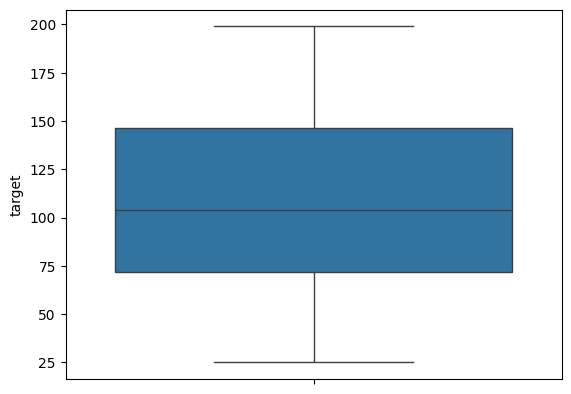

In [78]:
#Visualizations
# Boxplot of target with condition
sns.boxplot(y= "target", data=df[df["target"]<200])

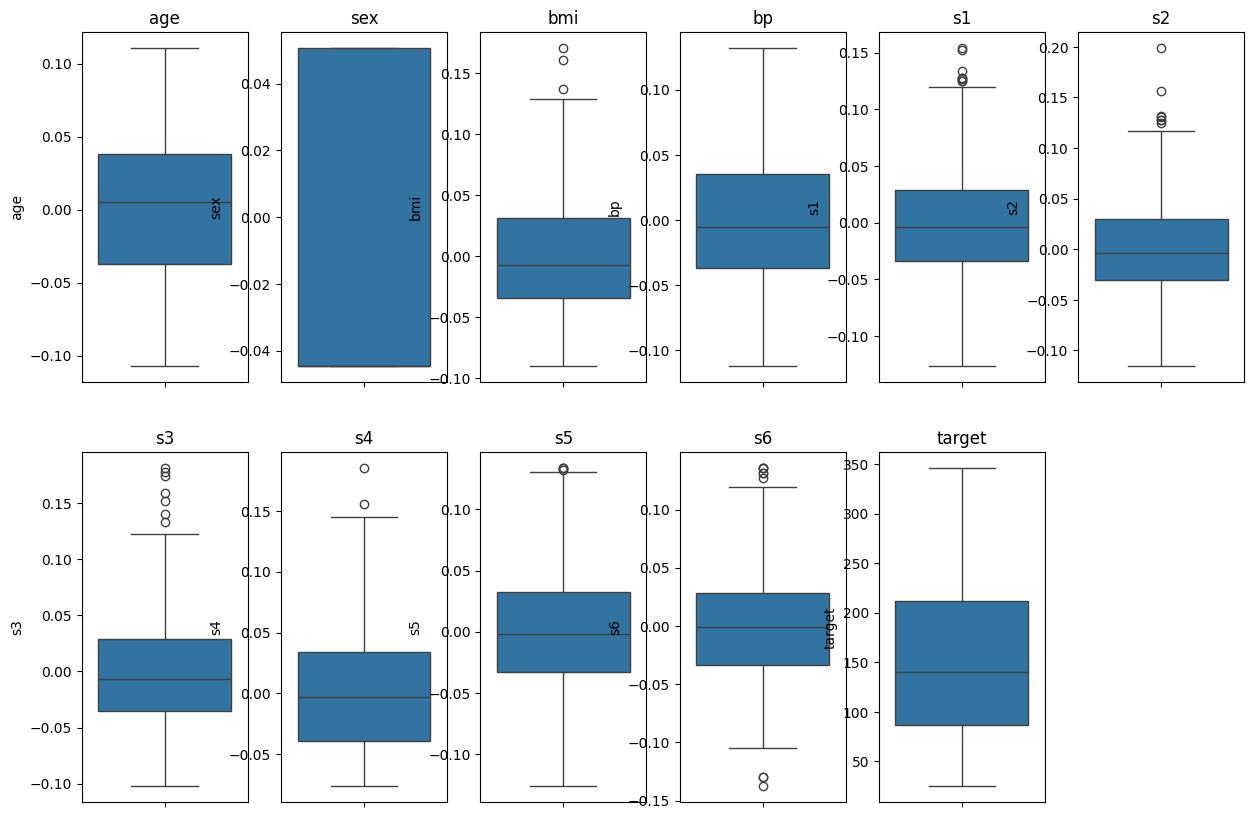

In [79]:
# Boxplot of all the 11 features
plt.figure(figsize=(15,10)) 
for i in range(len(df.columns)):
    plt.subplot(2,6, i+1)
    sns.boxplot(df, y=df.columns[i])
    plt.title(df.columns[i])
plt.show()

<Axes: xlabel='target', ylabel='Count'>

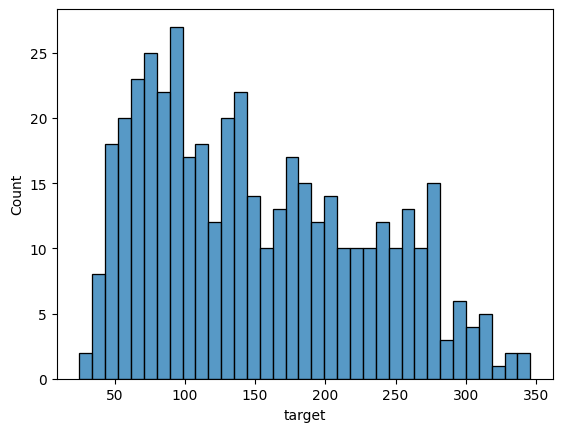

In [80]:
# Histogram
sns.histplot(df, x=df["target"], bins=35)


<Axes: >

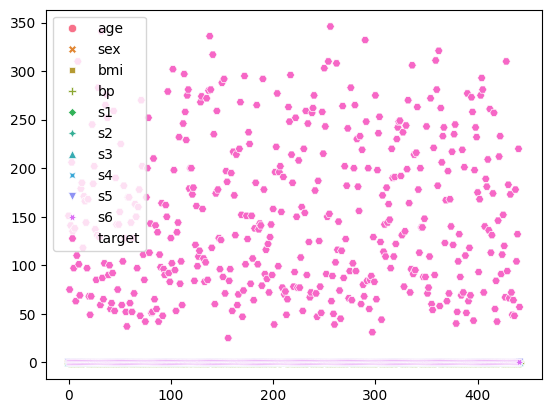

In [81]:
# Scatterplot of the dataset
sns.scatterplot(df, )

<Axes: xlabel='target', ylabel='bp'>

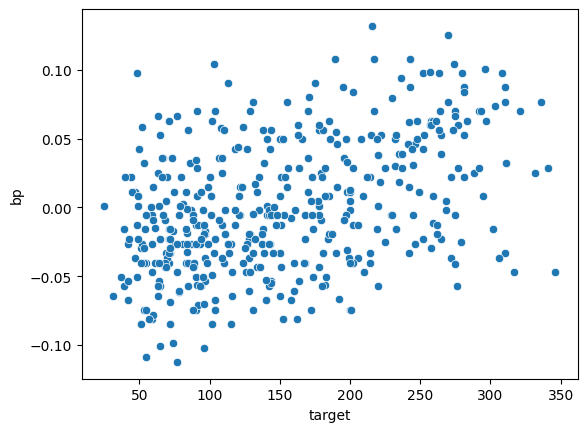

In [82]:
# scatter plot of the target
sns.scatterplot(df, x=df["target"], y=df["bp"])

<Axes: >

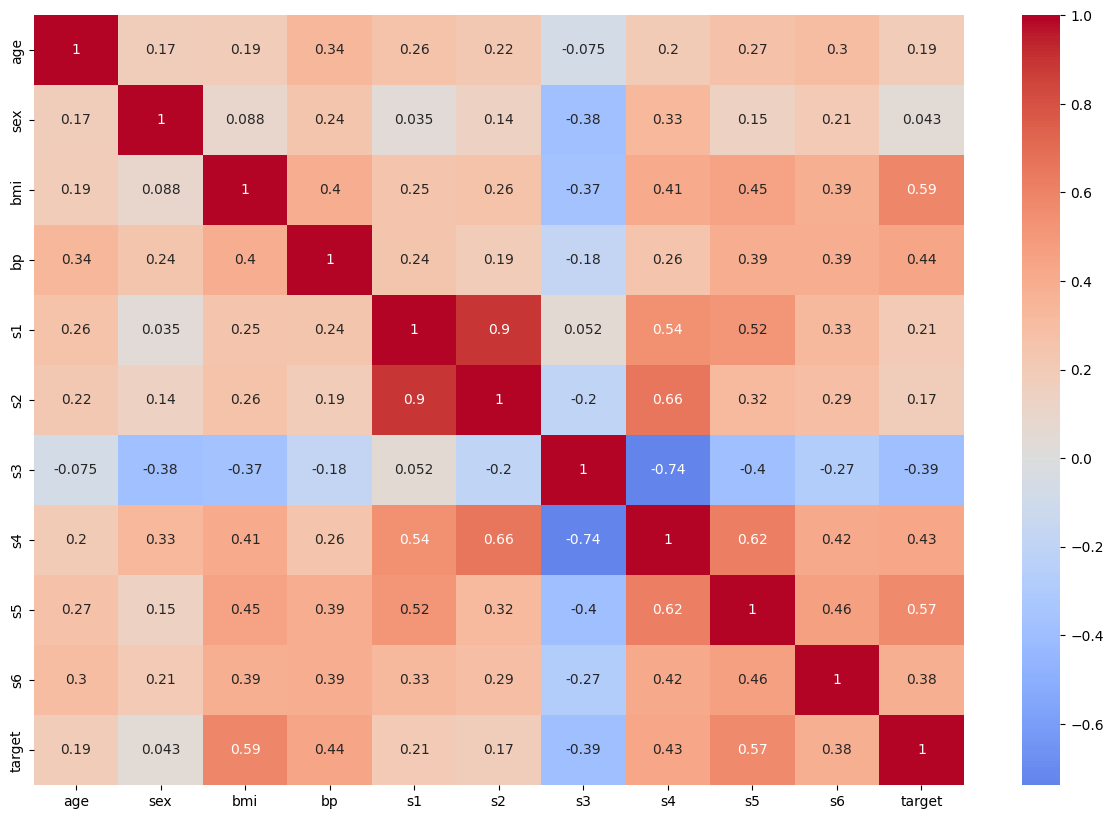

In [83]:
# Heatmap
plt.figure(figsize=(15,10))
df=df.corr()
sns.heatmap(df, annot=True, cmap="coolwarm", center=0)

In [84]:
# spliting the data into train and test  
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
# scaling the data 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#train models
models = {
    "linreg": LinearRegression(),
    "ridge": Ridge(alpha=1.0),
    "lasso": Lasso(alpha=0.01, max_iter=10000),
    "rf": RandomForestRegressor(n_estimators=300, random_state=42)
}
for name, m in models.items():
    m.fit(X_train_s, y_train)

# cell 6: evaluate & compare
rows = []
for name, m in models.items():
    y_pred = m.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))   # RMSE
    mae  = mean_absolute_error(y_test, y_pred)           # MAE
    r2   = r2_score(y_test, y_pred)                      # R²
    rows.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

results_df = pd.DataFrame(rows).sort_values("RMSE")
print(results_df)

    Model       RMSE        MAE        R2
1   ridge  53.777454  42.811999  0.454147
2   lasso  53.836493  42.795018  0.452947
0  linreg  53.853446  42.794095  0.452603
3      rf  54.921344  44.752022  0.430678


In [ ]:
# In diabetes the ridge regression outperforms the rest so its the ideal in this scenario